In [ ]:
#Ячейка 1. Импорты

!pip install onnxruntime
!pip install tensorflow
!pip install gdown
import gdown
from zipfile import ZipFile
from google.colab import files
import cv2
import numpy as np
import json
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 120.5 MB/s eta 0:00:00


In [ ]:
#Ячейка 2. Скачивание датасета
file_id = "10PhE0ZBgZJ44UJa0jDWxTrbOMylm4TPY"
url = f"https://drive.google.com/uc?id={file_id}"
output = "mydataset2.zip"

gdown.download(url, output, quiet=False)

with ZipFile("mydataset2.zip", 'r') as zip_ref:
    zip_ref.extractall("mydataset2")




Downloading...
From (original): https://drive.google.com/uc?id=10PhE0ZBgZJ44UJa0jDWxTrbOMylm4TPY
From (redirected): https://drive.google.com/uc?id=10PhE0ZBgZJ44UJa0jDWxTrbOMylm4TPY&confirm=t&uuid=ca74c4cd-a32e-456f-9019-c29b70fbdfd6
To: /content/mydataset2.zip
100%|██████████| 1.95G/1.95G [00:12<00:00, 160MB/s]


In [ ]:
print(os.listdir("mydataset2"))
print(os.listdir("mydataset2/mydataset2"))

['mydataset2']
['JSON', 'SPECS']


In [ ]:
import numpy as np
import json
import os

SPEC_DIR = "mydataset2/mydataset2/SPECS"
JSON_DIR = "mydataset2/mydataset2/JSON"

X = []
y = []

files = os.listdir(SPEC_DIR)

for f in files:
    if not f.endswith(".npy"):
        continue

    base = f.replace(".npy", "")

    spec_path = os.path.join(SPEC_DIR, f)
    json_path = os.path.join(JSON_DIR, base + ".json")

    if not os.path.exists(json_path):
        continue

    mel = np.load(spec_path) 

    T = 128
    if mel.shape[2] > T:
        mel = mel[:, :, :T]
    else:
        pad = T - mel.shape[2]
        mel = np.pad(mel, ((0,0),(0,0),(0,pad)))

    with open(json_path) as fjson:
        data = json.load(fjson)
        angle = data["angle"]

    X.append(mel)
    y.append(angle)



In [ ]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

y_sin = np.sin(np.deg2rad(y))
y_cos = np.cos(np.deg2rad(y))

y = np.stack([y_sin, y_cos], axis=1)

X = np.transpose(X, (0, 2, 3, 1))  # → (N, 128, 128, 3)

print("X shape:", X.shape)

X shape: (14604, 3, 128, 128)
y shape: (14604,)
X shape: (14604, 128, 128, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X.shape[1:]  # (3, 128, 128)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(padding='same'),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(padding='same'),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(padding='same'),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dense(2)  # sin, cos
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14604, 128, 128, 3)
y shape: (14604, 2)


In [ ]:
model.fit(
    X,
    y,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 115s 309ms/step - loss: 94.6244 - val_loss: 0.3099
Epoch 2/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 136s 372ms/step - loss: 0.2354 - val_loss: 0.1959
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 110s 300ms/step - loss: 0.1871 - val_loss: 0.1684
Epoch 4/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 115s 314ms/step - loss: 0.1642 - val_loss: 0.1516
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 112s 305ms/step - loss: 0.1466 - val_loss: 0.1650
Epoch 6/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 110s 301ms/step - loss: 0.1330 - val_loss: 0.1432
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 133s 365ms/step - loss: 0.1218 - val_loss: 0.1605
Epoch 8/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 115s 314ms/step - loss: 0.1119 - val_loss: 0.1180
Epoch 9/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 112s 306ms/step - loss: 0.0998 - val_loss: 0.1246
Epoch 10/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 113s 309ms/step - loss: 0.0905 - val_loss: 0.1087


In [9]:
history = model.fit(
    X,
    y,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 141s 382ms/step - loss: 0.9967 - val_loss: 0.3375
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 107s 293ms/step - loss: 0.3204 - val_loss: 0.3018
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 105s 287ms/step - loss: 0.2817 - val_loss: 0.2896
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 104s 285ms/step - loss: 0.2507 - val_loss: 0.2537
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 104s 283ms/step - loss: 0.2129 - val_loss: 0.2010
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 105s 286ms/step - loss: 0.1906 - val_loss: 0.1984
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 140s 383ms/step - loss: 0.1623 - val_loss: 0.1732
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 104s 284ms/step - loss: 0.1360 - val_loss: 0.1168
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 102s 280ms/step - loss: 0.1108 - val_loss: 0.1338
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 104s 284ms/step - loss: 0.0944 - val_loss: 0.0929
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 104s 285ms/step - loss: 0.0804 - val_loss: 0.0747
Epoch 12

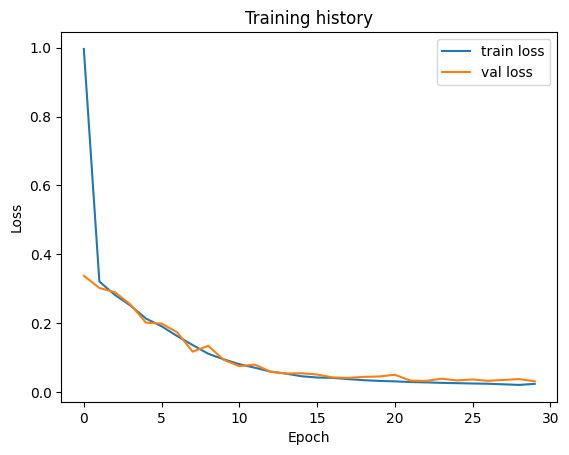

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training history')
plt.show()

In [11]:
#Ячейка. Экспорт
model.save("model.keras")
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

from google.colab import files
files.download("model.tflite")

Saved artifact at '/tmp/tmp2b7jaq_z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135603889653712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889654864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889653520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889652176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889654288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889653904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889652368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889652752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889654096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135603889655248: TensorSpec(shape=(), dtype=tf.resource, name=None)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>